# Graph Neural Networks for Drug Discovery
### A Foundational Learning Project

---

## Full Notebook Outline

| Section | Title | Status |
|---------|-------|--------|
| 0 | Project Framing | ✅ Implemented |
| 1 | Dataset Loading | ✅ Implemented |
| 2 | Molecular Representation | ✅ Implemented |
| 3 | Feature Engineering | 🔜 Coming next |
| 4 | Train/Test Split | 🔜 Coming next |
| 5 | Baseline Model (Morgan Fingerprints + RF) | 🔜 Coming next |
| 6 | Simple GCN Model | 🔜 Coming next |
| 7 | Training Loop | 🔜 Coming next |
| 8 | Evaluation | 🔜 Coming next |
| 9 | GIN Model + Comparison | 🔜 Coming next |
| 10 | Drug Development Interpretation | 🔜 Coming next |
| 11 | Optional Extensions | 🔜 Coming next |

---

**How to use this notebook:**
Run one section at a time. Read the explanation before each code cell. After running, check your output against the expected output described below each cell.

---
# Section 0: Project Framing

Before writing any code, let's make sure we understand what we're actually doing and why.

## What is drug discovery, in plain English?

Developing a new drug takes roughly 10–15 years and over a billion dollars. Most of that time and money is spent on **failure** — testing molecules that turn out to be toxic, don't work, or can't even reach the target organ.

The early stage of drug discovery looks like this:

```
You have a disease target (e.g. a protein that causes cancer)
    ↓
You need a molecule that binds to it and changes its behavior
    ↓
There are billions of possible drug-like molecules
    ↓
You cannot test all of them in the lab — that would take centuries
    ↓
So you use computation to PRIORITIZE which molecules to actually test
```

This prioritization step is called **virtual screening** or **computational screening**.

One huge part of it is **molecular property prediction**: given a molecule's structure, can we predict properties that matter for a drug?

Properties that matter include:
- **Solubility** — can the molecule dissolve in water? (If not, it can't travel through the bloodstream)
- **Blood-brain barrier penetration** — can it reach the brain? (Matters for neurological drugs)
- **Toxicity** — will it kill cells it shouldn't kill?
- **Binding affinity** — does it actually bind to the disease target?
- **Bioavailability** — can the body absorb and use it?

These properties are collectively called **ADMET** properties:
- **A**bsorption
- **D**istribution
- **M**etabolism
- **E**xcretion
- **T**oxicity

In this project, we will build a machine learning model that predicts **aqueous solubility** — one of the most fundamental and commonly predicted ADMET properties.

---

## Why GNNs? What's wrong with regular machine learning?

A molecule is not a list of numbers. It's a **graph**.

- Atoms are **nodes**
- Bonds between atoms are **edges**

Traditional machine learning needs a fixed-size vector as input. So the traditional approach was to convert molecules into fixed-length "fingerprints" — essentially a bag-of-features that ignores the graph structure.

**Graph Neural Networks (GNNs)** can operate directly on the graph structure. Instead of flattening the molecule into a fixed vector, the GNN lets each atom communicate with its bonded neighbors and build up a rich, learned representation of the molecule.

This is closer to how chemists actually think about molecules — as structured, connected objects where local chemical environment matters.

---

## What we ARE and are NOT claiming

| We ARE doing | We are NOT doing |
|---|---|
| Learning how to represent molecules as graphs | Discovering a real drug |
| Training a GNN to predict a molecular property from structure | Proving biological activity in a lab |
| Learning the core ML pipeline used in computational chemistry | Running wet-lab experiments |
| Building intuition for how GNNs capture chemical structure | Guaranteeing any prediction is accurate enough for real use |
| Understanding one piece of a larger drug discovery workflow | Replacing any part of clinical trials |

This project is a **pedagogical implementation** of a real and important technique. The same core ideas are used by pharmaceutical companies and research labs today — but the real versions use larger datasets, more features, more careful validation, and much more domain expertise.

---

## The pipeline we will build

```
SMILES string (text representation of a molecule)
    ↓
RDKit molecule object (parsed chemical structure)
    ↓
Molecular graph (atoms as nodes, bonds as edges)
    ↓
Atom features as node feature matrix  (shape: [num_atoms, num_features])
    ↓
Bond connections as edge index         (shape: [2, num_bonds*2])
    ↓
Graph Neural Network — message passing
    ↓
Graph-level molecular embedding        (shape: [1, hidden_dim])
    ↓
Linear layer — property prediction
    ↓
Predicted solubility value
    ↓
Comparison to actual measured value → RMSE, MAE, R²
```

Let's build it one step at a time.

---
# Section 1: Dataset Loading

**What we're doing:** Loading a real molecular dataset with measured solubility values.

**Why it matters:** We need real experimental data to train and evaluate our model. Without measured ground-truth values, we have nothing to learn from.

**The dataset: ESOL (Estimated SOLubility)**

ESOL is a classic benchmark dataset in computational chemistry, published by John Delaney in 2004. It contains:
- **1,128 organic molecules**
- Each molecule represented as a SMILES string
- Each molecule paired with its measured **aqueous solubility** in log mol/L

**What is SMILES?** SMILES stands for *Simplified Molecular Input Line Entry System*. It's a way to write a molecule's structure as a text string. For example:
- Water: `O`
- Ethanol: `CCO`
- Aspirin: `CC(=O)Oc1ccccc1C(=O)O`

**What is solubility?** Solubility measures how much of a substance dissolves in water. We measure it in log mol/L (the log scale is used because solubility spans many orders of magnitude). Higher values = more soluble.

**Why does solubility matter for drugs?** A drug needs to dissolve in bodily fluids to be absorbed and transported to where it needs to work. Poorly soluble drugs have low bioavailability — the body can't use them efficiently. Roughly 40% of drug candidates fail partly due to poor solubility.

## Step 1.1 — Install dependencies

We need two libraries that aren't pre-installed in Colab:
- **RDKit** — the standard open-source cheminformatics library. We'll use it to parse SMILES strings into molecule objects and extract atom/bond information.

The cell below installs RDKit. In Colab, this uses `pip`.

> **If this install fails:** The most common reason is a network timeout. Just re-run the cell. If it still fails, try restarting the Colab runtime and running again.

In [ ]:
# Install RDKit — the chemistry library we'll use throughout this project.
# This may take 30-60 seconds in Colab.
!pip install rdkit --quiet

print("Install complete. If you see no errors above, you're good to go.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 29.7 MB/s eta 0:00:00
Install complete. If you see no errors above, you're good to go.


## Step 1.2 — Import libraries

Let's import everything we need for this section and confirm our environment is working.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# RDKit — for chemistry
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem import rdMolDescriptors

# For displaying molecule images inside the notebook
from IPython.display import display, Image
import io

# Suppress RDKit warnings that aren't useful for learning
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

print("Imports successful.")

# Confirm RDKit version
from rdkit import __version__ as rdkit_version
print(f"RDKit version: {rdkit_version}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")

Imports successful.
RDKit version: 2026.03.2
Pandas version: 2.2.2
NumPy version:  2.0.2


## Step 1.3 — Load the ESOL dataset

We'll load the ESOL dataset directly from a publicly hosted CSV. This is the canonical version of the dataset as distributed by MoleculeNet.

The CSV has two columns we care about:
- `smiles` — the SMILES string representing the molecule
- `measured log solubility in mols per litre` — the experimentally measured solubility value

We'll rename that long column to `solubility` for readability.

> **What if the URL fails?** We include a fallback that downloads from an alternative source. If both fail, a manual download link is printed.

In [ ]:
# -------------------------------------------------------
# Load the ESOL solubility dataset
# -------------------------------------------------------

# Primary source: MoleculeNet's hosted version of the Delaney ESOL dataset
ESOL_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"

# Fallback source in case the primary is unavailable
ESOL_FALLBACK_URL = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"

try:
    df = pd.read_csv(ESOL_URL)
    print("Loaded from primary source.")
except Exception as e:
    print(f"Primary source failed ({e}). Trying fallback...")
    try:
        df = pd.read_csv(ESOL_FALLBACK_URL)
        print("Loaded from fallback source.")
    except Exception as e2:
        print(f"Both sources failed. Error: {e2}")
        print("Manual download: https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv")
        raise

print(f"\nDataset loaded. Shape: {df.shape}  ({df.shape[0]} molecules, {df.shape[1]} columns)")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  {col}")

Loaded from primary source.

Dataset loaded. Shape: (1128, 10)  (1128 molecules, 10 columns)

Column names:
  Compound ID
  ESOL predicted log solubility in mols per litre
  Minimum Degree
  Molecular Weight
  Number of H-Bond Donors
  Number of Rings
  Number of Rotatable Bonds
  Polar Surface Area
  measured log solubility in mols per litre
  smiles


### Understanding the ESOL Dataset Columns

Here is a breakdown of the features included in this dataset. While our GNN will learn its own features from the raw graph, these columns represent traditional chemical 'descriptors':

| Column Name | Description |
|:---|:---|
| **Compound ID** | The common name or identifier for the molecule (e.g., Aspirin, Benzene). |
| **smiles** | The text-based 'DNA' of the molecule. This is our primary input for the GNN. |
| **measured log solubility...** | **Our Target.** The actual experimental value we want our model to predict. |
| **ESOL predicted...** | This is the prediction made by the original 2004 'ESOL' linear model. We can use this as a benchmark. |
| **Molecular Weight** | The 'size' of the molecule. Heavier molecules often (but not always) dissolve more slowly. |
| **Number of Rings** | How many closed loops (like Benzene rings) are in the structure. More rings often mean lower solubility. |
| **Number of Rotatable Bonds** | A measure of how 'flexible' the molecule is. High flexibility can affect how easily a molecule fits into a crystal lattice. |
| **Polar Surface Area (PSA)** | Measures how much of the molecule's surface is 'polar' (likes water). Higher PSA usually helps solubility. |
| **H-Bond Donors** | Number of atoms (like O-H or N-H) that can form hydrogen bonds with water. More donors usually = better solubility. |
| **Minimum Degree** | A structural graph property representing the minimum number of bonds attached to any single non-hydrogen atom. |


**Notes from Pranav:**
1. More Benzene Rings means less solubility because benzene rings are hydrophobic and non polar
2. More rotatable bonds = more flexiblity = easier to be soluble

## Step 1.4 — Clean up column names

The original column name is very long. Let's rename it to something manageable.

We also keep the compound name if present, just for human readability.

In [ ]:
# The target column has a long name — rename it for convenience.
# We look for it by checking which column contains 'solubility' in its name.

solubility_col = [c for c in df.columns if 'solubility' in c.lower()]
print(f"Found solubility column(s): {solubility_col}")

# Rename to 'solubility'
df = df.rename(columns={solubility_col[0]: 'solubility'})

# Look for a compound name column to keep for readability
name_col = [c for c in df.columns if 'compound' in c.lower() or 'name' in c.lower()]
print(f"Found name column(s): {name_col}")

# Keep only the columns we need for this project
keep_cols = ['smiles', 'solubility']
if name_col:
    keep_cols = [name_col[0]] + keep_cols
    df = df.rename(columns={name_col[0]: 'compound_name'})
    keep_cols[0] = 'compound_name'

df = df[keep_cols].copy()

print(f"\nDataset after cleanup:")
print(df.head(5).to_string())

Found solubility column(s): ['ESOL predicted log solubility in mols per litre', 'measured log solubility in mols per litre']
Found name column(s): ['Compound ID']

Dataset after cleanup:
  compound_name                                                  smiles  solubility
0     Amigdalin  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O       -0.974
1      Fenfuram                                  Cc1occc1C(=O)Nc2ccccc2      -2.885
2        citral                                    CC(C)=CCCC(C)=CC(=O)      -2.579
3        Picene                      c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43      -6.618
4     Thiophene                                                 c1ccsc1      -2.232


## Step 1.5 — Basic exploration

Before building any model, always look at your data.

We want to know:
1. How many molecules do we have?
2. Are there missing values?
3. What does the target (solubility) look like?
4. What does a SMILES string actually look like?

This step matters because:
- Missing SMILES strings would crash the molecule parser later
- Understanding the target distribution tells us if this is an easy or hard regression problem
- It builds intuition for what the data represents

In [ ]:
# -------------------------------------------------------
# 1. Size and missing values
# -------------------------------------------------------

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total molecules:    {len(df)}")
print(f"Columns:            {list(df.columns)}")

print("\nMissing values per column:")
print(df.isnull().sum())

# -------------------------------------------------------
# 2. Target variable statistics
# -------------------------------------------------------

print("\n" + "=" * 50)
print("TARGET VARIABLE: Solubility (log mol/L)")
print("=" * 50)
stats = df['solubility'].describe()
print(f"  Mean:   {stats['mean']:.3f}")
print(f"  Std:    {stats['std']:.3f}")
print(f"  Min:    {stats['min']:.3f}")
print(f"  Max:    {stats['max']:.3f}")
print(f"  Median: {df['solubility'].median():.3f}")

print("\nInterpretation:")
print("  Values near 0  → moderately soluble (dissolves well)")
print("  Values near -5 → poorly soluble (hard to dissolve)")
print("  Values near +1 → highly soluble")
print("  This is log scale: a difference of 1 = 10x difference in solubility")

DATASET OVERVIEW
Total molecules:    1128
Columns:            ['compound_name', 'smiles', 'solubility']

Missing values per column:
compound_name    0
smiles           0
solubility       0
dtype: int64

TARGET VARIABLE: Solubility (log mol/L)
  Mean:   -2.988
  Std:    1.683
  Min:    -9.702
  Max:    1.091
  Median: -2.870

Interpretation:
  Values near 0  → moderately soluble (dissolves well)
  Values near -5 → poorly soluble (hard to dissolve)
  Values near +1 → highly soluble
  This is log scale: a difference of 1 = 10x difference in solubility


## Step 1.6 — Look at some SMILES examples

Let's print a few SMILES strings so you can see what the raw input looks like. At this stage, you don't need to be able to read SMILES — just notice that it's a text string encoding molecular structure.

In [ ]:
# -------------------------------------------------------
# Show some SMILES examples across the solubility range
# -------------------------------------------------------

print("=" * 60)
print("EXAMPLE MOLECULES — sorted by solubility")
print("=" * 60)

# Get examples from different parts of the solubility range
df_sorted = df.sort_values('solubility')

# Take 3 from the least soluble, 2 from the middle, 3 from the most soluble
examples = pd.concat([
    df_sorted.head(3),
    df_sorted.iloc[len(df_sorted)//2 - 1 : len(df_sorted)//2 + 1],
    df_sorted.tail(3)
])

for idx, row in examples.iterrows():
    name = row.get('compound_name', f'Molecule {idx}')
    print(f"\n  Name:        {name}")
    print(f"  SMILES:      {row['smiles']}")
    print(f"  Solubility:  {row['solubility']:.3f} log mol/L")

    # Add a human-readable interpretation
    if row['solubility'] > -1:
        print(f"  Category:    Highly soluble")
    elif row['solubility'] > -3:
        print(f"  Category:    Moderately soluble")
    elif row['solubility'] > -5:
        print(f"  Category:    Slightly soluble")
    else:
        print(f"  Category:    Poorly soluble")

EXAMPLE MOLECULES — sorted by solubility

  Name:        hexacosane
  SMILES:      CCCCCCCCCCCCCCCCCCCCCCCCCC
  Solubility:  -9.702 log mol/L
  Category:    Poorly soluble

  Name:        2,2',3,3',4,4',5,5',6,6'-PCB
  SMILES:      Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(Cl)c2Cl 
  Solubility:  -9.589 log mol/L
  Category:    Poorly soluble

  Name:        2,2',3,3',4,4',5,5'-PCB
  SMILES:      Clc1cc(c(Cl)c(Cl)c1Cl)c2cc(Cl)c(Cl)c(Cl)c2Cl
  Solubility:  -8.468 log mol/L
  Category:    Poorly soluble

  Name:        metalaxyl
  SMILES:      COCC(=O)N(C(C)C(=O)OC)c1c(C)cccc1C 
  Solubility:  -2.870 log mol/L
  Category:    Moderately soluble

  Name:        thioanisole
  SMILES:      c1ccccc1SC
  Solubility:  -2.870 log mol/L
  Category:    Moderately soluble

  Name:        alloxantin
  SMILES:      C1(=O)NC(=O)NC(=O)C1(O)C2(O)C(=O)NC(=O)NC2(=O)
  Solubility:  0.919 log mol/L
  Category:    Highly soluble

  Name:        Lactose
  SMILES:      OCC1OC(OC2C(O)C(O)C(O)OC2CO)C(O)C(O)C1

## Step 1.7 — Validate that RDKit can parse all SMILES strings

Before we go further, we need to check that every SMILES string in the dataset can actually be converted into a molecule object by RDKit.

**What is an RDKit molecule object?** It's a Python object representing a parsed, validated molecule. From it, we can extract atoms, bonds, coordinates, and features. If RDKit can't parse a SMILES string, it returns `None`.

**What can go wrong:** Some SMILES strings in datasets have typos, unusual notation, or represent molecules with valence errors. We want to catch these now rather than have them silently fail later.

In [ ]:
# -------------------------------------------------------
# Try to parse every SMILES string with RDKit
# -------------------------------------------------------

def try_parse_smiles(smiles):
    """Returns the RDKit mol object, or None if parsing fails."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol  # This is None if RDKit couldn't parse it
    except Exception:
        return None

print("Attempting to parse all SMILES strings...")
df['mol'] = df['smiles'].apply(try_parse_smiles)

# Count successes and failures
n_total = len(df)
n_valid = df['mol'].notna().sum()
n_invalid = df['mol'].isna().sum()

print(f"\nTotal molecules:      {n_total}")
print(f"Successfully parsed:  {n_valid}")
print(f"Failed to parse:      {n_invalid}")

if n_invalid > 0:
    print("\nFailed SMILES strings:")
    failed = df[df['mol'].isna()]
    for _, row in failed.iterrows():
        print(f"  SMILES: {row['smiles']}")
    print("\nDropping these from the dataset.")
    df = df[df['mol'].notna()].copy()

print(f"\nFinal dataset size: {len(df)} molecules")

## Step 1.8 — Visualize the solubility distribution

Let's plot a histogram of the solubility values. This tells us:
- Whether the distribution is roughly normal (good for regression)
- Whether there are extreme outliers
- What range of values our model needs to predict

This is a routine but important step before training any regression model.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Histogram of solubility values ---
ax1 = axes[0]
ax1.hist(df['solubility'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.axvline(df['solubility'].mean(), color='orange', linewidth=2, linestyle='--', label=f"Mean: {df['solubility'].mean():.2f}")
ax1.axvline(df['solubility'].median(), color='red', linewidth=2, linestyle=':', label=f"Median: {df['solubility'].median():.2f}")
ax1.set_xlabel("Solubility (log mol/L)", fontsize=12)
ax1.set_ylabel("Number of molecules", fontsize=12)
ax1.set_title("Distribution of Solubility Values (ESOL Dataset)", fontsize=13)
ax1.legend(fontsize=10)

# Add solubility category labels on x-axis
ax1.axvspan(-12, -5, alpha=0.06, color='red', label='Poorly soluble')
ax1.axvspan(-5, -3, alpha=0.06, color='orange')
ax1.axvspan(-3, -1, alpha=0.06, color='yellow')
ax1.axvspan(-1, 5, alpha=0.06, color='green')

# Annotation
y_top = ax1.get_ylim()[1]
ax1.text(-10, y_top * 0.95, 'Poorly\nsoluble', ha='center', fontsize=8, color='darkred')
ax1.text(-4, y_top * 0.95, 'Slightly\nsoluble', ha='center', fontsize=8, color='darkorange')
ax1.text(-2, y_top * 0.95, 'Moderately\nsoluble', ha='center', fontsize=8, color='goldenrod')
ax1.text(0.5, y_top * 0.95, 'Highly\nsoluble', ha='center', fontsize=8, color='darkgreen')

# --- Right: SMILES string length distribution ---
ax2 = axes[1]
smiles_lengths = df['smiles'].apply(len)
ax2.hist(smiles_lengths, bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.5)
ax2.axvline(smiles_lengths.mean(), color='orange', linewidth=2, linestyle='--', label=f"Mean: {smiles_lengths.mean():.1f} chars")
ax2.set_xlabel("SMILES string length (characters)", fontsize=12)
ax2.set_ylabel("Number of molecules", fontsize=12)
ax2.set_title("SMILES String Length Distribution\n(a rough proxy for molecule size)", fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('section1_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nSMILES length stats:")
print(f"  Min:    {smiles_lengths.min()} characters")
print(f"  Max:    {smiles_lengths.max()} characters")
print(f"  Median: {smiles_lengths.median():.0f} characters")
print("\n  Longer SMILES usually = larger/more complex molecule = more atoms/bonds = larger graph")

## Step 1.9 — Visualize a few molecules

Let's draw the actual 2D structure of a few molecules to make the SMILES strings feel real. RDKit can generate 2D molecular diagrams.

This is purely visual — it helps build the intuition that a SMILES string is just a compact text encoding of a real molecular structure.

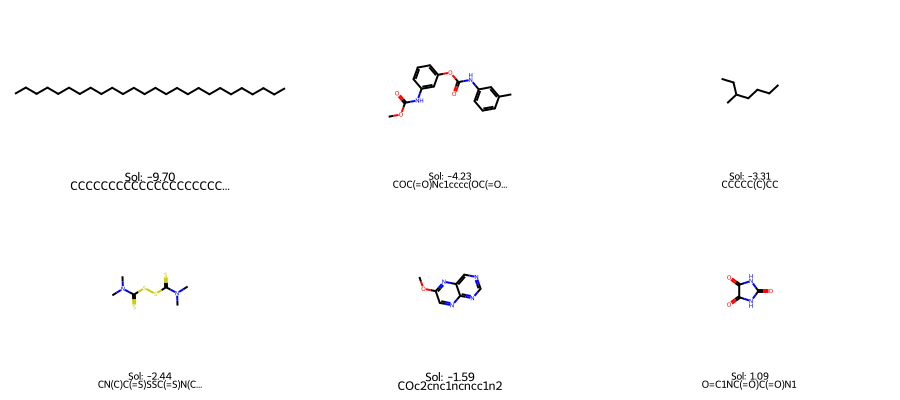


These 6 molecules span the full solubility range in the dataset.
Each is represented by a SMILES string. Each will become a graph.

Notice: smaller, simpler molecules tend to be more soluble.
Large, flat, aromatic molecules tend to be poorly soluble.


In [18]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display, Image as DisplayImage # Alias IPython.display.Image
import PIL.Image # Explicitly import PIL.Image
import io # Import io for BytesIO

# Pick 6 interesting molecules across the solubility range
df_sorted = df.sort_values('solubility').reset_index(drop=True)
indices = [0, len(df)//5, 2*len(df)//5, 3*len(df)//5, 4*len(df)//5, len(df)-1]
sample = df_sorted.iloc[indices]

# Draw molecules in a grid
mols = list(sample['mol'])
labels = [
    f"Sol: {row['solubility']:.2f}\n{row['smiles'][:20]}{'...' if len(row['smiles'])>20 else ''}"
    for _, row in sample.iterrows()
]

# Draw the image. This returns an IPython.display.Image object in Colab.
img_display = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 200),
    legends=labels
)

# Save and display
# Check if it's an IPython.display.Image and extract bytes for saving
if isinstance(img_display, DisplayImage):
    img_bytes = io.BytesIO(img_display.data)
    img_pil_for_save = PIL.Image.open(img_bytes)
    img_pil_for_save.save('section1_molecules.png')
else:
    # If for some reason it's already a PIL Image (e.g., in a different environment)
    img_display.save('section1_molecules.png')

display(img_display) # Display the original IPython.display.Image object

print("\nThese 6 molecules span the full solubility range in the dataset.")
print("Each is represented by a SMILES string. Each will become a graph.")
print("\nNotice: smaller, simpler molecules tend to be more soluble.")
print("Large, flat, aromatic molecules tend to be poorly soluble.")

---
## Section 1 Complete — What You Should Understand

Before moving on, make sure you can answer these questions:

1. **What dataset did we load?** ESOL — 1,128 organic molecules with measured aqueous solubility values.

2. **What is the target variable?** Solubility in log mol/L. Higher = more soluble in water.

3. **What is a SMILES string?** A text encoding of a molecule's structure. `CCO` is ethanol. `CC(=O)Oc1ccccc1C(=O)O` is aspirin.

4. **Why solubility?** It's a fundamental ADMET property. A drug that can't dissolve can't be absorbed.

5. **What does our data look like?** ~1,100 molecules. Solubility ranges from about -12 to +2 log mol/L. Roughly normally distributed. No significant missing values.

---

## What output you should see

After running all cells in Section 1, you should see:
- A printout confirming `~1128 molecules loaded` with no missing values
- Solubility statistics (mean around -3, std around 2)
- A few example SMILES strings with their solubility values
- A histogram showing the distribution of solubility values (roughly bell-shaped)
- A grid of 6 molecular structure diagrams

If molecules don't render visually, it's okay — the text output is what matters for now.

---

## What Section 2 will do

In Section 2, we take individual SMILES strings and convert them into **molecular graphs**.

You will:
- Parse a SMILES string into an RDKit molecule object
- Extract all atoms and bonds from the molecule
- Print the atom types, bond types, and connectivity
- Build the mental model: **atoms are nodes, bonds are edges**
- Understand what `edge_index` means in a graph

This is the step where we move from "chemistry" to "graph theory."

**When you're ready, move on to Section 2.**

---
# Section 2: Molecular Representation

**What we're doing:** Taking SMILES strings and converting them into explicit graph structures — lists of atoms (nodes) and bonds (edges).

**Why it matters for drug development:** A GNN can only operate on a graph. Before we can train anything, we need to convert every molecule into a format the network understands: a node feature matrix and an edge list. This step is the bridge between chemistry and machine learning.

**Input:** A SMILES string — e.g. `CC(=O)Oc1ccccc1C(=O)O` (aspirin)

**Output:** A graph description:
- A list of atoms with their properties (the nodes)
- A list of bonds connecting those atoms (the edges)

**The core idea:**

```
Molecule → Graph

  Atom  →  Node   (each atom is a point in the graph)
  Bond  →  Edge   (each bond is a connection between two nodes)
```

A graph is just a set of nodes and a set of edges. A molecule is already a graph — we just need to make that explicit.

**What can go wrong:** Some SMILES strings represent molecules with unusual valence (e.g., charged atoms, radicals). RDKit may sanitize or reject these. We already filtered them out in Section 1, so we're safe here.

**Simplification we're making:** We're ignoring 3D coordinates. Real molecules exist in 3D space, and 3D structure matters for binding. We're working with 2D graph topology only — atoms and which atoms they're bonded to. This is a meaningful simplification but a reasonable one for property prediction.

## Step 2.1 — Pick a few molecules to inspect

We'll work with 4 molecules chosen to show variety:
- A very simple molecule (few atoms)
- A molecule with a benzene ring (aromatic)
- A mid-size drug-like molecule
- Aspirin (familiar reference point)

For each one we'll manually walk through its graph structure.

In [ ]:
# Four molecules to explore — chosen for variety
# We define them manually here so this section is self-contained
# (doesn't depend on which rows happened to load from the CSV)

example_molecules = [
    {"name": "Ethanol",        "smiles": "CCO"},
    {"name": "Benzene",        "smiles": "c1ccccc1"},
    {"name": "Aspirin",        "smiles": "CC(=O)Oc1ccccc1C(=O)O"},
    {"name": "Caffeine",       "smiles": "Cn1cnc2c1c(=O)n(c(=O)n2C)C"},
]

# Parse each SMILES into an RDKit molecule object
for entry in example_molecules:
    mol = Chem.MolFromSmiles(entry['smiles'])
    entry['mol'] = mol

print("Molecules loaded:")
for e in example_molecules:
    m = e['mol']
    print(f"  {e['name']:15s}  SMILES: {e['smiles']}")
    print(f"  {'':15s}  Atoms: {m.GetNumAtoms()}  |  Bonds: {m.GetNumBonds()}")
    print()

## Step 2.2 — Atoms as nodes

In RDKit, once you have a molecule object you can iterate over its atoms.

Each atom has properties we can read:
- **Symbol** — the element (C, N, O, ...)
- **Atomic number** — integer ID for the element (Carbon=6, Nitrogen=7, Oxygen=8, ...)
- **Degree** — how many bonds this atom has to other heavy atoms
- **Formal charge** — whether the atom carries a positive or negative charge
- **Is aromatic** — whether the atom is part of an aromatic ring like benzene

These properties will become the **node features** in our GNN — the numbers we feed into the network for each atom.

For now, just read them. We'll convert them into feature vectors in Section 3.

In [ ]:
# Print every atom in each molecule with its key properties

for entry in example_molecules:
    mol = entry['mol']
    print("=" * 55)
    print(f"  {entry['name']}  |  SMILES: {entry['smiles']}")
    print(f"  {mol.GetNumAtoms()} atoms (nodes)  |  {mol.GetNumBonds()} bonds (edges)")
    print("=" * 55)
    print(f"  {'Node':>5}  {'Symbol':>6}  {'AtomicNum':>9}  {'Degree':>6}  {'Charge':>6}  {'Aromatic':>8}")
    print(f"  {'-'*5}  {'-'*6}  {'-'*9}  {'-'*6}  {'-'*6}  {'-'*8}")

    for atom in mol.GetAtoms():
        print(f"  {atom.GetIdx():>5}  "
              f"{atom.GetSymbol():>6}  "
              f"{atom.GetAtomicNum():>9}  "
              f"{atom.GetDegree():>6}  "
              f"{atom.GetFormalCharge():>6}  "
              f"{str(atom.GetIsAromatic()):>8}")
    print()

print("Key observations:")
print("  - Each atom has an integer index (Node 0, 1, 2, ...) — this is its ID in the graph")
print("  - Benzene's carbons all show Aromatic=True — they're in a ring with delocalized electrons")
print("  - Degree = number of heavy-atom bonds — Hydrogen bonds are implicit in SMILES")
print("  - These properties are what we'll turn into feature vectors in Section 3")

## Step 2.3 — Bonds as edges

Each bond connects two atoms by their index. That's all an edge is in a graph — a pair of node IDs.

Bonds also have a **type**:
- **SINGLE** — one pair of shared electrons (e.g. C-C in ethane)
- **DOUBLE** — two pairs of shared electrons (e.g. C=O in aspirin's carbonyl)
- **TRIPLE** — three pairs (rare in drug-like molecules)
- **AROMATIC** — delocalized electrons in a ring (e.g. benzene)

Bond type tells you something about the electron density and geometry around those atoms — both of which affect how a molecule behaves chemically.

In a GNN, bonds can become **edge features** (optional). For now, we print them to build intuition.

In [ ]:
# Print every bond in each molecule

for entry in example_molecules:
    mol = entry['mol']
    print("=" * 45)
    print(f"  {entry['name']}  — Bonds (Edges)")
    print("=" * 45)
    print(f"  {'Bond':>5}  {'Atom_i':>7}  {'Atom_j':>7}  {'Type':>10}")
    print(f"  {'-'*5}  {'-'*7}  {'-'*7}  {'-'*10}")

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        btype = bond.GetBondTypeAsDouble()  # 1.0=single, 1.5=aromatic, 2.0=double
        bname = str(bond.GetBondType()).split('.')[-1]  # e.g. 'SINGLE'
        print(f"  {bond.GetIdx():>5}  "
              f"{i:>7}  "
              f"{j:>7}  "
              f"{bname:>10}")
    print()

## Step 2.4 — Building the edge index

In PyTorch Geometric (which we'll use in Section 3+), the graph connectivity is stored as an **edge_index** tensor.

`edge_index` has shape `[2, num_edges]`.

- Row 0: the **source** atom index for each edge
- Row 1: the **destination** atom index for each edge

**Important:** graphs in GNNs are treated as **undirected but stored as directed**. Every bond A→B also becomes B→A. So if a molecule has 5 bonds, the edge_index has 10 columns.

Why? During message passing, atom A needs to receive information from atom B, AND atom B needs to receive information from atom A. Storing both directions makes that easy.

Example for ethanol (CCO — 3 atoms, 2 bonds):
```
Bond 0-1 and bond 1-2

edge_index = [[0, 1, 1, 2],
              [1, 0, 2, 1]]

Shape: [2, 4]  ← 2 bonds × 2 directions
```

In [ ]:
import torch

def mol_to_edge_index(mol):
    """
    Convert an RDKit molecule's bonds into a PyTorch edge_index tensor.
    Each bond A-B becomes two directed edges: A->B and B->A.
    Returns a LongTensor of shape [2, num_bonds * 2].
    """
    src = []
    dst = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        src += [i, j]  # both directions
        dst += [j, i]
    return torch.tensor([src, dst], dtype=torch.long)


print("Edge index for each molecule:")
print()

for entry in example_molecules:
    mol = entry['mol']
    edge_index = mol_to_edge_index(mol)

    print(f"  {entry['name']}")
    print(f"    Atoms (nodes):        {mol.GetNumAtoms()}")
    print(f"    Bonds:                {mol.GetNumBonds()}")
    print(f"    edge_index shape:     {list(edge_index.shape)}   ← [2, bonds×2]")
    print(f"    edge_index row 0:     {edge_index[0].tolist()}  (source atoms)")
    print(f"    edge_index row 1:     {edge_index[1].tolist()}  (destination atoms)")
    print()

## Step 2.5 — Visualize the graph structure

Let's draw the graph explicitly — nodes as circles, edges as lines — using NetworkX.

This makes the graph structure visible alongside the 2D molecular diagram. The two images represent the same thing: one is drawn as a chemist would draw it, the other as a graph theorist would.

**NetworkX** is a standard Python library for working with graphs. We won't use it in the GNN itself — PyTorch Geometric handles graphs differently — but it's useful for visualization.

In [ ]:
import networkx as nx
from rdkit.Chem import Draw

# Visualize 3 molecules: molecular diagram (RDKit) alongside graph diagram (NetworkX)
molecules_to_plot = example_molecules[:3]  # ethanol, benzene, aspirin

fig, axes = plt.subplots(len(molecules_to_plot), 2, figsize=(10, 4 * len(molecules_to_plot)))

bond_type_colors = {
    'SINGLE':   'gray',
    'DOUBLE':   'blue',
    'AROMATIC': 'green',
    'TRIPLE':   'red',
}

for row_idx, entry in enumerate(molecules_to_plot):
    mol  = entry['mol']
    name = entry['name']

    # --- Left: RDKit 2D molecular diagram ---
    ax_mol = axes[row_idx][0]
    img = Draw.MolToImage(mol, size=(300, 200))
    ax_mol.imshow(img)
    ax_mol.axis('off')
    ax_mol.set_title(f"{name}\n(chemical structure)", fontsize=11)

    # --- Right: NetworkX graph ---
    ax_graph = axes[row_idx][1]
    G = nx.Graph()

    # Add nodes with element label
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), label=atom.GetSymbol())

    # Add edges with bond type
    edge_colors = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bname = str(bond.GetBondType()).split('.')[-1]
        G.add_edge(i, j, bond_type=bname)
        edge_colors.append(bond_type_colors.get(bname, 'black'))

    pos    = nx.spring_layout(G, seed=42)
    labels = nx.get_node_attributes(G, 'label')

    nx.draw_networkx_nodes(G, pos, ax=ax_graph, node_color='lightyellow',
                           node_size=800, edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax_graph, font_size=11, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax_graph, edge_color=edge_colors, width=2)
    ax_graph.set_title(f"{name}\n(graph: nodes=atoms, edges=bonds)", fontsize=11)
    ax_graph.axis('off')

    # Legend for first row only
    if row_idx == 0:
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0],[0], color=c, linewidth=2, label=t)
                           for t, c in bond_type_colors.items()]
        ax_graph.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.suptitle("Same molecule — two representations", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('section2_graphs.png', dpi=120, bbox_inches='tight')
plt.show()

print("Left = how a chemist draws a molecule")
print("Right = how a GNN sees it: labeled nodes connected by edges")
print("They contain exactly the same information.")

---
## Section 2 Complete — What You Should Understand

1. **A molecule is a graph.** Atoms are nodes. Bonds are edges. This isn't a metaphor — it's a direct mapping.

2. **Each atom has properties** — symbol, atomic number, degree, charge, aromaticity. These will become node feature vectors in Section 3.

3. **Each bond has a type** — single, double, aromatic. These can optionally become edge features.

4. **`edge_index` shape is `[2, num_bonds * 2]`** — every bond is stored twice (both directions) so message passing can flow both ways.

5. **The graph representation discards 3D coordinates** — we're working with topology (connectivity) only. This is a simplification that works well for property prediction.

---

## What output you should see

- A table of atoms for each molecule with symbol, atomic number, degree, charge, aromaticity
- A table of bonds with source/destination atom indices and bond type
- `edge_index` tensors printed for each molecule — check that the shape is `[2, num_bonds * 2]`
- Side-by-side plots: RDKit 2D structure (left) and NetworkX graph (right)

For ethanol (CCO):
- 3 atoms: C(0), C(1), O(2)
- 2 bonds → edge_index shape `[2, 4]`
- edge_index: `[[0, 1, 1, 2], [1, 0, 2, 1]]`

---

## What Section 3 will do

Now that we can see atoms and bonds, Section 3 turns them into **numbers**.

Each atom becomes a **feature vector** — a fixed-length list of numbers encoding its properties. For example:
```
Carbon atom → [6, 2, 0, 0, 0, 1]  ← [atomic_num, degree, charge, ...]
```
Stack all atom vectors into a matrix `x` of shape `[num_atoms, num_features]`.
Combine with `edge_index` and the solubility label `y`, and you have one complete PyTorch Geometric `Data` object — a single training example for the GNN.

**When you're ready, move on to Section 3.**